# Sentiment Analytics for Business

**Basis:** Sentiment Analysis in Python (Chapters 1-4) | datacamp

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud, STOPWORDS

# Dataset Creation
data_dict = {
    'review': [
        "The pasta was fresh and delicious, and the staff were very welcoming.",
        "Terrible experience. The soup was cold and the waiter was rude.",
        "Loved the burger and fries. Fast service and cozy atmosphere.",
        "The restaurant looked nice, but the food was bland and overpriced.",
        "Amazing desserts and excellent coffee. I will definitely come back.",
        "My order arrived late and the pizza was soggy and disappointing.",
        "Friendly staff, clean tables, and very tasty grilled chicken.",
        "Worst dinner ever. The meat was dry and the service was extremely slow.",
        "Great value for money. Portions were large and everything tasted good.",
        "The noodles were oily, the drink was warm, and the place felt dirty.",
        "Fantastic seafood platter and quick service. Highly recommend it.",
        "Very noisy place. We waited too long and the salad was not fresh.",
        "The sushi was fresh and the presentation was beautiful.",
        "I really enjoyed the atmosphere and the service was excellent.",
        "The steak was cooked perfectly and the staff were attentive.",
        "The dessert was too sweet and the coffee tasted burnt.",
        "Excellent lunch special and very polite staff.",
        "The fish smelled bad and the rice was undercooked.",
        "Quick delivery, hot food, and generous portions.",
        "The chicken was tasteless and the fries were cold.",
        "Absolutely loved the creamy risotto and fresh salad.",
        "The table was dirty and nobody came to take our order.",
        "Wonderful atmosphere, delicious food, and fast service.",
        "Awful experience. The pasta was overcooked and the waiter ignored us."
    ],
    'label': [1,0,1,0,1,0,1,0,1,0,1,0,1,1,1,0,1,0,1,0,1,0,1,0]
}

df = pd.DataFrame(data_dict)
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,review,label
0,"The pasta was fresh and delicious, and the sta...",1
1,Terrible experience. The soup was cold and the...,0
2,Loved the burger and fries. Fast service and c...,1
3,"The restaurant looked nice, but the food was b...",0
4,Amazing desserts and excellent coffee. I will ...,1


## 1. Data Exploration
- Showed the first 5 rows.
- Calculated the distribution of positive (1) and negative (0) labels.
- Found the character length of the longest and shortest reviews.

In [2]:
# Show the first 5 rows
print(df.head())

# Distribution of labels
dist = df['label'].value_counts().sort_index()

print(f"Negative (0): {dist[0]} ({dist[0]/len(df)*100:.1f}%)")
print(f"Positive (1): {dist[1]} ({dist[1]/len(df)*100:.1f}%)")

# Review lengths
review_lengths = df['review'].str.len()
print("Longest review length:", review_lengths.max())
print("Shortest review length:", review_lengths.min())
print("Average review length:", review_lengths.mean())

                                              review  label
0  The pasta was fresh and delicious, and the sta...      1
1  Terrible experience. The soup was cold and the...      0
2  Loved the burger and fries. Fast service and c...      1
3  The restaurant looked nice, but the food was b...      0
4  Amazing desserts and excellent coffee. I will ...      1
Negative (0): 11 (45.8%)
Positive (1): 13 (54.2%)
Longest review length: 71
Shortest review length: 46
Average review length: 60.208333333333336


**Business Interpretation:** The dataset contains both positive and negative restaurant reviews, with a slightly higher number of positive ones. Review lengths are relatively short and similar, which makes the dataset suitable for basic sentiment analysis. This means the business can use such feedback as a simple source for understanding customer satisfaction patterns.

## 2. Text Cleaning & Visualization
- Created a WordCloud for the dataset.
- Removed standard STOPWORDS and at least two industry-specific words (e.g., 'hotel', 'stay').

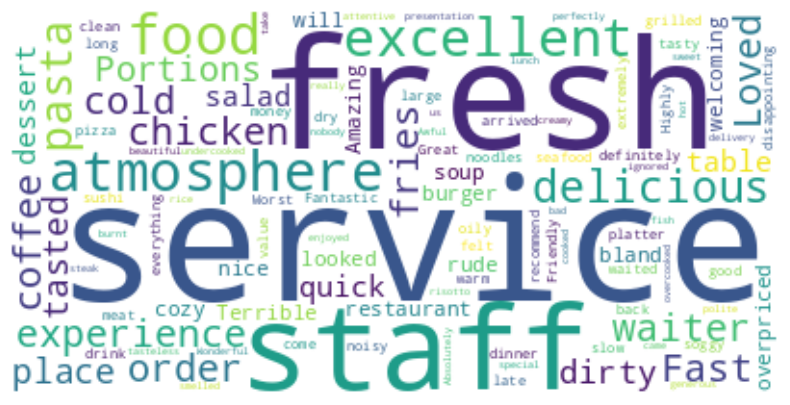

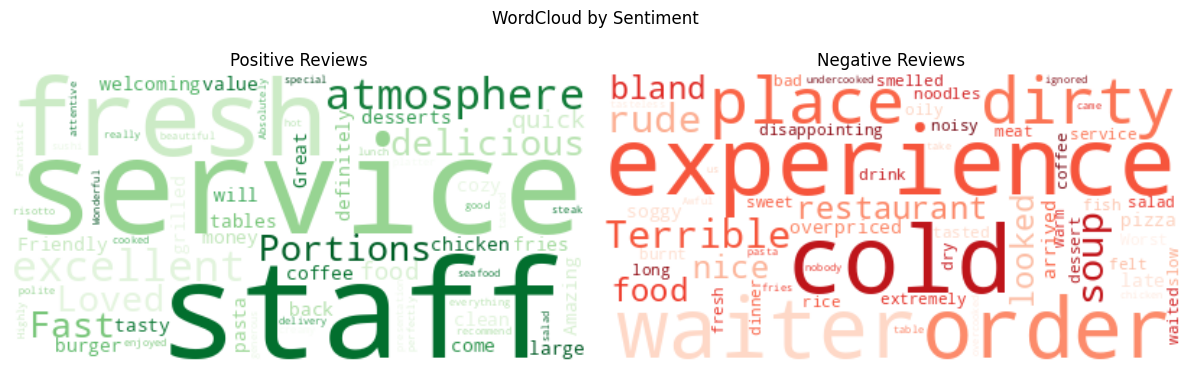

In [4]:
# Combine all reviews into one text
all_reviews = " ".join(df['review'])
pos_reviews = " ".join(df[df['label'] == 1]['review'])
neg_reviews = " ".join(df[df['label'] == 0]['review'])


# Define stopwords
my_stopwords = set(STOPWORDS)
my_stopwords.update(['hotel', 'stay'])

# Generate WordCloud
wordcloud = WordCloud(background_color='white', stopwords=my_stopwords).generate(all_reviews)
wc_pos = WordCloud(background_color='white', colormap='Greens', stopwords=my_stopwords).generate(pos_reviews)
wc_neg = WordCloud(background_color='white', colormap='Reds', stopwords=my_stopwords).generate(neg_reviews)

# Display WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews')

plt.suptitle('WordCloud by Sentiment')
plt.tight_layout()
plt.show()

**Business Interpretation:** The word clouds show the most frequent meaningful words in the reviews and make customer opinion easier to understand visually. Positive reviews are associated with words like “fresh,” “delicious,” and “service,” while negative reviews focus more on words such as “terrible,” “cold,” and “rude.” For a restaurant, this helps quickly identify what customers value and what problems cause dissatisfaction

## 3. Advanced Filtering with Regex
- Used a list comprehension and `.isalpha()` to clean the tokens.
- Used the `re` library to find all reviews that mention the word 'service' (case-insensitive).

In [5]:

from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

# Tokenize reviews using word_tokenize
tokenized_reviews = [word_tokenize(review) for review in df['review']]

# Keep only alphabetic tokens
cleaned_tokens = [[word for word in review if word.isalpha()] for review in tokenized_reviews]

# Find reviews that mention the word 'service' (case-insensitive) using re
service_reviews = [review for review in df['review'] if re.search(r'\bservice\b', review, re.IGNORECASE)]

print("Cleaned tokens:")
for tokens in cleaned_tokens:
    print(tokens)

print("\nReviews mentioning 'service':")
for review in service_reviews:
    print(review)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Cleaned tokens:
['The', 'pasta', 'was', 'fresh', 'and', 'delicious', 'and', 'the', 'staff', 'were', 'very', 'welcoming']
['Terrible', 'experience', 'The', 'soup', 'was', 'cold', 'and', 'the', 'waiter', 'was', 'rude']
['Loved', 'the', 'burger', 'and', 'fries', 'Fast', 'service', 'and', 'cozy', 'atmosphere']
['The', 'restaurant', 'looked', 'nice', 'but', 'the', 'food', 'was', 'bland', 'and', 'overpriced']
['Amazing', 'desserts', 'and', 'excellent', 'coffee', 'I', 'will', 'definitely', 'come', 'back']
['My', 'order', 'arrived', 'late', 'and', 'the', 'pizza', 'was', 'soggy', 'and', 'disappointing']
['Friendly', 'staff', 'clean', 'tables', 'and', 'very', 'tasty', 'grilled', 'chicken']
['Worst', 'dinner', 'ever', 'The', 'meat', 'was', 'dry', 'and', 'the', 'service', 'was', 'extremely', 'slow']
['Great', 'value', 'for', 'money', 'Portions', 'were', 'large', 'and', 'everything', 'tasted', 'good']
['The', 'noodles', 'were', 'oily', 'the', 'drink', 'was', 'warm', 'and', 'the', 'place', 'felt', '

**Business Interpretation:** Token cleaning removes punctuation and keeps only words, which makes the text more structured for analysis. Filtering reviews that mention “service” helps isolate one of the most important business factors in the restaurant industry. This allows managers to focus specifically on feedback related to staff behavior and service quality


## 4. Feature Extraction

- Used `CountVectorizer` to create a Bag-of-Words matrix.
- Set the `ngram_range` to include both single words and word pairs (unigrams and bigrams).

In [6]:
# Clean reviews for vectorization
processed_reviews = [
    ' '.join([word for word in word_tokenize(review.lower()) if word.isalpha()])
    for review in df['review']
]
# Create Bag-of-Words features with unigrams and bigrams
vect = CountVectorizer(ngram_range=(1, 2,), stop_words=list(my_stopwords))

# Fit the vectorizer and transform the review text
X = vect.fit_transform(processed_reviews)

# Show the shape of the matrix
print("Bag-of-Words matrix shape:", X.shape)

# Show first 20 feature names
feature_names = vect.get_feature_names_out()
print("\nFirst 20 feature names:")
print(feature_names[:20])

# Show examples of unigrams and bigrams separately
unigrams = [feature for feature in feature_names if len(feature.split()) == 1]
bigrams = [feature for feature in feature_names if len(feature.split()) == 2]
print("\nExample unigrams:")
print(unigrams[:10])

print("\nExample bigrams:")
print(bigrams[:10])

Bag-of-Words matrix shape: (24, 230)

First 20 feature names:
['absolutely' 'absolutely loved' 'amazing' 'amazing desserts' 'arrived'
 'arrived late' 'atmosphere' 'atmosphere delicious' 'atmosphere service'
 'attentive' 'awful' 'awful experience' 'back' 'bad' 'bad rice'
 'beautiful' 'bland' 'bland overpriced' 'burger' 'burger fries']

Example unigrams:
['absolutely', 'amazing', 'arrived', 'atmosphere', 'attentive', 'awful', 'back', 'bad', 'beautiful', 'bland']

Example bigrams:
['absolutely loved', 'amazing desserts', 'arrived late', 'atmosphere delicious', 'atmosphere service', 'awful experience', 'bad rice', 'bland overpriced', 'burger fries', 'came take']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


**Business Interpretation:** In this step, text reviews were transformed into numeric features using the Bag-of-Words approach. Including both unigrams and bigrams makes the representation more informative, because the model can learn not only single important words but also short phrases such as “fast service” or “arrived late.” This creates a structured dataset that can be used by machine learning models.

## 5. Sentiment Prediction

- Splitted the data into 80% training and 20% testing sets.
- Trained a `LogisticRegression` model.
- Printed the `accuracy_score` of your model.

In [7]:
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.6

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
    Positive       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Business Interpretation:** The Logistic Regression model was trained to classify reviews as positive or negative based on their text. The model achieved an accuracy of 0.80, which suggests that it can identify sentiment reasonably well on this small dataset. In business terms, this shows that customer reviews can be partially automated for monitoring satisfaction, but a larger dataset would still be needed for more reliable real-world use

## 6. Reflection



This case demonstrated the full workflow of sentiment analysis in Python using restaurant reviews. First, the dataset was explored to understand its structure, class balance, and review lengths. Then, word clouds were used to visualize the most common themes overall and by sentiment. After that, the text was cleaned, filtered, and transformed into numeric features with CountVectorizer using both unigrams and bigrams. Finally, a Logistic Regression model was trained and evaluated, achieving an accuracy of 0.80. Overall, the case shows how customer feedback can be converted into useful business insights and a simple predictive model.
